#  Regresión Lineal: y = a + bx

In [2]:
import numpy
import matplotlib.pyplot as plt
import joblib

In [3]:
X = joblib.load('variables/temperatura.joblib')
Y = joblib.load('variables/ventas_helado.joblib')

## Gráfica de puntos

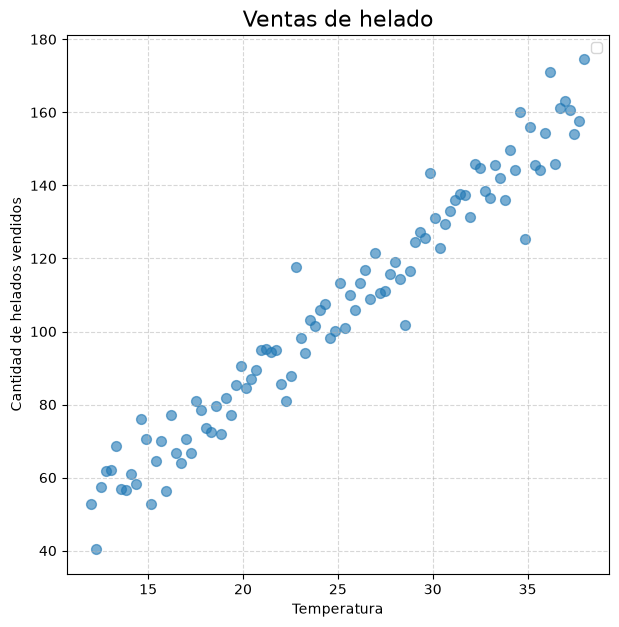

In [4]:
plt.figure(figsize=(7, 7))
plt.scatter(X, Y, s=50, alpha=0.6)
plt.title('Ventas de helado', fontsize=16)
plt.ylabel('Cantidad de helados vendidos')
plt.xlabel('Temperatura')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend('')
plt.show()

## Cálculo de a y b

### Cálculo de b por pendiente promedio

In [5]:
pendientes = []
for i in range(1, len(X)):
    pendiente = (Y[i] - Y[i-1]) / (X[i] - X[i-1])
    pendientes.append(pendiente)

print(f'Pendientes: {pendientes}')
print(f'Promedio: {float(numpy.mean(pendientes))}')


Pendientes: [np.float64(-47.72824687112722), np.float64(64.59984980262224), np.float64(16.906364959096145), np.float64(1.5651787537042277), np.float64(24.900405586170752), np.float64(-44.497940866738915), np.float64(-1.9021296686173181), np.float64(16.647227559627122), np.float64(-10.091535152843738), np.float64(67.7803015020568), np.float64(-20.630948416348435), np.float64(-68.20397203759299), np.float64(45.15890137768993), np.float64(20.719632373175237), np.float64(-52.21773986354036), np.float64(79.50479347098577), np.float64(-39.38009445230465), np.float64(-10.879237787485545), np.float64(24.723826077527143), np.float64(-13.644780140951642), np.float64(53.2689910670974), np.float64(-8.95780833957492), np.float64(-18.657860330335758), np.float64(-4.5659407489538735), np.float64(27.049269214697706), np.float64(-28.5480545663972), np.float64(37.64801430045698), np.float64(-18.103058467319304), np.float64(31.130900622190637), np.float64(19.495244656762925), np.float64(-22.9991567757891

### Calculo de a por iteración

In [6]:
b = float(numpy.mean(pendientes))
a = -1000000
limite = 1000000

while a < limite:
    print('-'*30)
    print(f'a antes de la diferencia: {a}')
    T = [ a + b*x for x in X ]
    diferencia = abs(numpy.mean([ _t - _y for _t, _y in zip(T, Y) ]))
    print(f'diferencia {diferencia}')

    if diferencia < 0.01:
        break

    a += diferencia - diferencia * 0.1

print(f'Valor final de a: {a}')

------------------------------
a antes de la diferencia: -1000000
diferencia 999989.4774438485
------------------------------
a antes de la diferencia: -100009.47030053637
diferencia 99998.94774438489
------------------------------
a antes de la diferencia: -10010.417330589975
diferencia 9999.894774438504
------------------------------
a antes de la diferencia: -1010.5120335953216
diferencia 999.9894774438515
------------------------------
a antes de la diferencia: -110.52150389585529
diferencia 99.99894774438519
------------------------------
a antes de la diferencia: -20.522450925908615
diferencia 9.99989477443851
------------------------------
a antes de la diferencia: -11.522545628913957
diferencia 0.9999894774438499
------------------------------
a antes de la diferencia: -10.622555099214491
diferencia 0.09999894774438467
------------------------------
a antes de la diferencia: -10.532556046244546
diferencia 0.009999894774440108
Valor final de a: -10.532556046244546


### Resultado

In [7]:
joblib.dump(a, 'variables/a.joblib')
joblib.dump(b, 'variables/b.joblib')
print(f'Valor de a: {a}')
print(f'Valor de b: {b}')
print(f'Ecuacion: y = {a: .3f} + {b: .3f} x')

Valor de a: -10.532556046244546
Valor de b: 4.677448753386233
Ecuacion: y = -10.533 +  4.677 x
